In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
train_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset_v6_window120.csv"
)

test_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/test_dataset_v6_window120.csv"
)

print(train_dataset.shape)
print(test_dataset.shape)

(242005, 198)
(65580, 198)


In [4]:
behavior_map = {
    "NORMAL1": "NORMAL",
    "NORMAL2": "NORMAL"
}

train_dataset["behavior"] = (
    train_dataset["behavior"]
    .replace(behavior_map)
)

test_dataset["behavior"] = (
    test_dataset["behavior"]
    .replace(behavior_map)
)

print(train_dataset["behavior"].value_counts())

print()

print(test_dataset["behavior"].value_counts())

behavior
NORMAL        115753
AGGRESSIVE     63491
DROWSY         62761
Name: count, dtype: int64

behavior
DROWSY        35903
AGGRESSIVE    15137
NORMAL        14540
Name: count, dtype: int64


In [5]:
target_column = "behavior"

feature_columns = [

    col

    for col in train_dataset.columns

    if col not in [

        "behavior",
        "driver",
        "trip",
        "road_type"

    ]

]

X_train = train_dataset[feature_columns]
X_test = test_dataset[feature_columns]

y_train = train_dataset[target_column]
y_test = test_dataset[target_column]

print(X_train.shape)
print(X_test.shape)

(242005, 194)
(65580, 194)


In [6]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)

y_test = label_encoder.transform(y_test)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


# XGBoost Tuning v2





In [7]:
xgb_model_v2 = XGBClassifier(

    random_state=42,

    objective="multi:softprob",
    num_class=3,

    n_estimators=500,

    learning_rate=0.03,

    max_depth=5,

    min_child_weight=3,

    gamma=0.1,

    subsample=0.9,

    colsample_bytree=0.9,

    reg_alpha=0.1,

    reg_lambda=2,

    eval_metric="mlogloss"

)

In [8]:
xgb_model_v2.fit(
    X_train,
    y_train
)

print("XGBoost Tuning v2 trained successfully!")

XGBoost Tuning v2 trained successfully!


In [9]:
xgb_pred_v2 = xgb_model_v2.predict(
    X_test
)

xgb_pred_v2[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
accuracy = accuracy_score(
    y_test,
    xgb_pred_v2
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7004


In [11]:
print(
    classification_report(
        y_test,
        xgb_pred_v2,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.89      0.87      0.88     15137
      DROWSY       0.93      0.54      0.69     35903
      NORMAL       0.44      0.91      0.60     14540

    accuracy                           0.70     65580
   macro avg       0.76      0.77      0.72     65580
weighted avg       0.81      0.70      0.71     65580



In [12]:
xgb_model = XGBClassifier(

    random_state=42,

    n_estimators=700,

    max_depth=8,

    learning_rate=0.03,

    subsample=0.9,

    colsample_bytree=0.9,

    min_child_weight=2,

    gamma=0.1,

    reg_alpha=0.1,

    reg_lambda=1.2,

    objective="multi:softmax",

    num_class=3,

    eval_metric="mlogloss"

)

In [13]:
xgb_model_v2.fit(
    X_train,
    y_train
)

print("XGBoost Tuning v2 trained successfully!")

XGBoost Tuning v2 trained successfully!


In [14]:
xgb_pred_v2 = xgb_model_v2.predict(
    X_test
)

xgb_pred_v2[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [15]:
accuracy = accuracy_score(
    y_test,
    xgb_pred_v2
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7004


In [16]:
print(
    classification_report(
        y_test,
        xgb_pred_v2,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.89      0.87      0.88     15137
      DROWSY       0.93      0.54      0.69     35903
      NORMAL       0.44      0.91      0.60     14540

    accuracy                           0.70     65580
   macro avg       0.76      0.77      0.72     65580
weighted avg       0.81      0.70      0.71     65580



In [17]:
probabilities = xgb_model_v2.predict_proba(X_test)

print(probabilities.shape)

(65580, 3)


In [18]:
print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [19]:
drowsy_probability = probabilities[:, 1]

print(drowsy_probability[:20])

[0.15609404 0.16060919 0.15901983 0.16077895 0.16061424 0.1648323
 0.15496422 0.15376136 0.15376136 0.15304698 0.16299509 0.16299509
 0.16347112 0.16347112 0.16347112 0.16347112 0.16347112 0.15903734
 0.16213183 0.16207609]


In [20]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_threshold(threshold):

    pred = xgb_model_v2.predict(X_test)

    pred_new = pred.copy()

    drowsy_prob = probabilities[:, 1]

    # DROWSY olasılığı threshold'u geçerse
    pred_new[drowsy_prob >= threshold] = 1

    accuracy = accuracy_score(y_test, pred_new)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        pred_new,
        average=None,
        labels=[0, 1, 2]
    )

    return {
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Drowsy Precision": precision[1],
        "Drowsy Recall": recall[1],
        "Drowsy F1": f1[1]
    }

In [21]:
thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

results = []

for t in thresholds:

    results.append(
        evaluate_threshold(t)
    )

results = pd.DataFrame(results)

results

,Threshold,Accuracy,Drowsy Precision,Drowsy Recall,Drowsy F1
0,0.30,0.750030,0.883706,0.680667,0.769010
1,0.35,0.734294,0.902310,0.632092,0.743407
2,0.40,0.720921,0.916167,0.595382,0.721735
3,0.45,0.709317,0.928729,0.564382,0.702101
4,0.50,0.700442,0.934070,0.544161,0.687692


In [22]:
from sklearn.metrics import confusion_matrix

pred_030 = xgb_model_v2.predict(X_test)
pred_030[drowsy_probability >= 0.30] = 1

cm = confusion_matrix(y_test, pred_030)

print(cm)

[[13065   574  1498]
 [ 1116 24438 10349]
 [  214  2642 11684]]


In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred_030,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.91      0.86      0.88     15137
      DROWSY       0.88      0.68      0.77     35903
      NORMAL       0.50      0.80      0.61     14540

    accuracy                           0.75     65580
   macro avg       0.76      0.78      0.76     65580
weighted avg       0.80      0.75      0.76     65580



In [24]:
thresholds = [
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

results = []

for t in thresholds:
    results.append(evaluate_threshold(t))

results = pd.DataFrame(results)

results

,Threshold,Accuracy,Drowsy Precision,Drowsy Recall,Drowsy F1
0,0.15,0.771028,0.799486,0.831351,0.815107
1,0.20,0.770555,0.835573,0.777484,0.805483
2,0.25,0.762702,0.862770,0.728992,0.790260
3,0.30,0.750030,0.883706,0.680667,0.769010
4,0.35,0.734294,0.902310,0.632092,0.743407
5,0.40,0.720921,0.916167,0.595382,0.721735
6,0.45,0.709317,0.928729,0.564382,0.702101
7,0.50,0.700442,0.934070,0.544161,0.687692


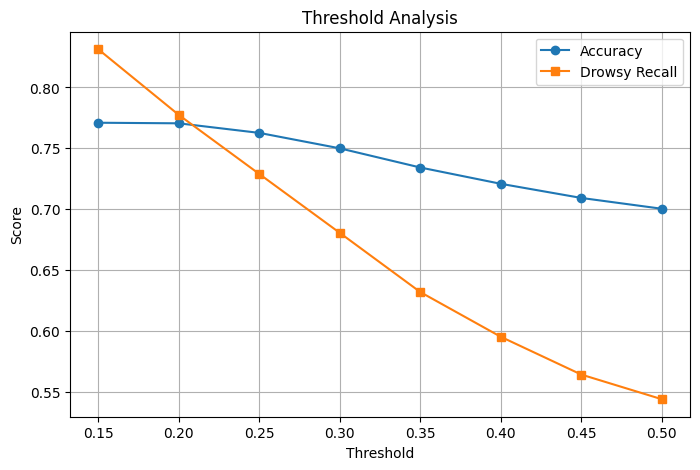

In [25]:
plt.figure(figsize=(8,5))

plt.plot(
    results["Threshold"],
    results["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    results["Threshold"],
    results["Drowsy Recall"],
    marker="s",
    label="Drowsy Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")

plt.grid(True)
plt.legend()

plt.show()

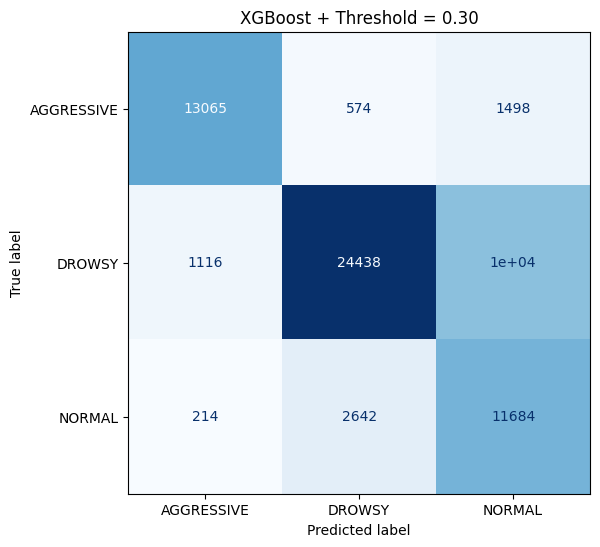

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    pred_030
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("XGBoost + Threshold = 0.30")
plt.show()

In [27]:
pred_015 = xgb_model_v2.predict(X_test)
pred_015[drowsy_probability >= 0.15] = 1

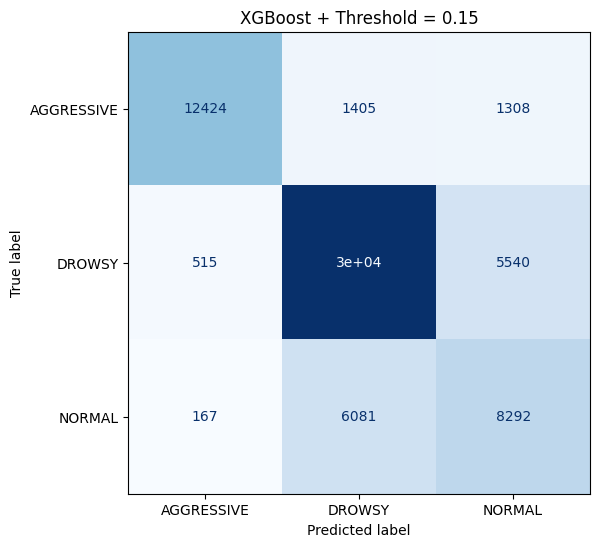

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_015)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("XGBoost + Threshold = 0.15")

plt.show()